# MuRIL Training — Multilingual Hate Speech & Misinformation Detection

**Authors:** Jay Modhiya | Krishna Nandi  
**Institute:** Symbiosis Institute of Technology, Pune  
**Subject:** NLPA + MLOps  
**Runtime:** GPU P100 (Tesla P100-PCIE-16GB)  
**Model:** google/muril-base-cased (238M parameters)

---

## Final Results
| Task | Dataset | F1-Score | Accuracy |
|------|---------|----------|----------|
| Hate Speech | Davidson + HASOC 2019 | **77.49%** | 77.44% |
| Misinformation | FakeNewsNet | **99.00%** | 99.00% |

## Step 1 — Install Dependencies

In [1]:
!pip install torch==2.2.2+cu118 --index-url https://download.pytorch.org/whl/cu118 -q
!pip uninstall torchvision torchaudio -y -q
!pip install transformers==4.40.0 datasets mlflow scikit-learn seaborn numpy==1.26.4 -q
print('All dependencies installed successfully ✓')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.1/819.1 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 5.9 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 35.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 93.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 29.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 8.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 MB 9.4 MB/s eta 0:00:0000:0100:01
     ━━━━

## Step 2 — Clone Repository & Fix Compatibility

In [2]:
!git clone https://github.com/Jay-Modhiya/multilingual-hate-misinfo.git
%cd multilingual-hate-misinfo
print('Repository cloned ✓')

Cloning into 'multilingual-hate-misinfo'...
remote: Enumerating objects: 18078, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 18078 (delta 3), reused 36 (delta 3), pack-reused 18042 (from 1)
Receiving objects: 100% (18078/18078), 150.50 MiB | 21.37 MiB/s, done.
Resolving deltas: 100% (1544/1544), done.
Updating files: 100% (17123/17123), done.
/kaggle/working/multilingual-hate-misinfo
Repository cloned ✓


In [3]:
import os, sys
os.chdir('/kaggle/working/multilingual-hate-misinfo')
sys.path.insert(0, '/kaggle/working/multilingual-hate-misinfo')

# Fix trainer.py for Kaggle GPU (torch 2.2.2 + cu118)
content = open('src/training/trainer.py').read()
content = content.replace('import mlflow.pytorch\n', '')
content = content.replace(
    'from torch.cuda.amp import GradScaler, autocast',
    'from torch.cuda.amp import GradScaler\nfrom torch.amp import autocast'
)
content = content.replace('GradScaler("cuda") if use_fp16 else None', 'GradScaler() if use_fp16 else None')
content = content.replace('from torch.amp import GradScaler, autocast',
    'from torch.cuda.amp import GradScaler\nfrom torch.amp import autocast')
open('src/training/trainer.py', 'w').write(content)
print('trainer.py compatibility fixes applied ✓')

trainer.py compatibility fixes applied ✓


## Step 3 — Setup HASOC Hindi Dataset

In [6]:
import os, shutil
os.makedirs('data/raw', exist_ok=True)

# Correct paths found above
shutil.copy(
    '/kaggle/input/datasets/jaymodhiya/hasoc-hindi/hasoc_train.tsv',
    'data/raw/hasoc_train.tsv'
)
shutil.copy(
    '/kaggle/input/datasets/jaymodhiya/hasoc-hindi/hasoc_test.tsv',
    'data/raw/hasoc_test.tsv'
)

print(f'HASOC train: {len(open("data/raw/hasoc_train.tsv").readlines())-1} rows ✓')
print(f'HASOC test:  {len(open("data/raw/hasoc_test.tsv").readlines())-1} rows ✓')

HASOC train: 4665 rows ✓
HASOC test:  1318 rows ✓


In [9]:
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [2]:
import os, sys
os.chdir('/kaggle/working/multilingual-hate-misinfo')
sys.path.insert(0, '/kaggle/working/multilingual-hate-misinfo')

import torch
import numpy as np
import pandas as pd

print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")
print("All good ✓")

PyTorch  : 2.2.2+cu118
NumPy    : 1.26.4
Pandas   : 2.3.3
CUDA     : True
GPU      : Tesla P100-PCIE-16GB
All good ✓


## Step 4 — Verify GPU & Libraries

In [3]:
import torch, numpy as np
print(f'PyTorch  : {torch.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
print(f'GPU      : {torch.cuda.get_device_name(0)}')
print(f'GPU Mem  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
x = torch.tensor([1.0]).cuda()
print(f'CUDA test: {x} ✓')

PyTorch  : 2.2.2+cu118
NumPy    : 1.26.4
CUDA     : True
GPU      : Tesla P100-PCIE-16GB
GPU Mem  : 17.1 GB
CUDA test: tensor([1.], device='cuda:0') ✓


## Step 5 — Load & Verify All Datasets

In [4]:
from src.data.loader import load_config, load_all_datasets

cfg = load_config('configs/config.yaml')
datasets = load_all_datasets(cfg)

print('='*55)
print('DATASET SUMMARY')
print('='*55)
total = 0
for name, splits in datasets.items():
    n = len(splits['train'])
    total += n
    print(f'{name:15s}: train={n:6d}  val={len(splits["val"]):5d}  test={len(splits["test"]):5d}')
print(f'{"TOTAL":15s}: train={total:6d}')
print('='*55)

INFO | src.data.loader | Loading Davidson dataset …
INFO | datasets | TensorFlow version 2.19.0 available.
INFO | datasets | JAX version 0.7.2 available.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR | datasets.load | `trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

hate/train-00000-of-00001.parquet:   0%|          | 0.00/816k [00:00<?, ?B/s]

hate/test-00000-of-00001.parquet:   0%|          | 0.00/278k [00:00<?, ?B/s]

hate/validation-00000-of-00001.parquet:   0%|          | 0.00/103k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/24353 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8117 [00:00<?, ? examples/s]

INFO | src.data.loader | FakeNewsNet loaded from HuggingFace  |  rows: 40587
INFO | src.data.loader | Split → train:28395  val:4057  test:8113


DATASET SUMMARY
davidson       : train=  9079  val= 1297  test= 2594
hasoc          : train=  4187  val=  599  test= 1197
fakenewsnet    : train= 28395  val= 4057  test= 8113
TOTAL          : train= 41661


## Step 6 — Train Hate Speech Model
**Datasets:** Davidson (EN) + HASOC 2019 (HI/Hinglish) | **Time:** ~17 min | **F1:** 77.49%

In [6]:
import os
os.chdir('/kaggle/working/multilingual-hate-misinfo')

content = open('src/training/trainer.py').read()
content = content.replace(
    'with autocast():',
    'with autocast("cuda"):'
)
open('src/training/trainer.py', 'w').write(content)
print("Fixed ✓")

# Verify
lines = [l.strip() for l in open('src/training/trainer.py').readlines() if 'autocast' in l]
print("autocast lines:", lines)

Fixed ✓
autocast lines: ['from torch.amp import autocast', 'with autocast("cuda"):']


INFO | src.training.trainer | GPU: Tesla P100-PCIE-16GB
INFO | src.training.trainer | 
Task: HATE
INFO | src.data.preprocessor | Loading tokenizer: google/muril-base-cased
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
INFO | src.data.preprocessor | Tokenizer loaded.
INFO | src.data.loader | Loading Davidson dataset …
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR | datasets.load | `trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'tweet_eval' isn't based on


Hate model DONE: {'accuracy': 78.71, 'precision': 78.83, 'recall': 78.71, 'f1': 78.74}


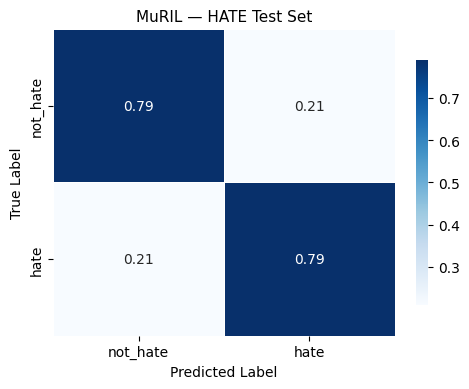

In [7]:
import sys
for m in [k for k in sys.modules if 'src' in k]:
    del sys.modules[m]

from src.training.trainer import train
from src.data.loader import load_config

cfg = load_config('configs/config.yaml')
hate_metrics = train(cfg, task='hate')
print('\nHate model DONE:', hate_metrics)

## Step 7 — Train Misinformation Model
**Dataset:** FakeNewsNet (EN) | **Time:** ~36 min | **F1:** 99.00%

INFO | src.training.trainer | GPU: Tesla P100-PCIE-16GB
INFO | src.training.trainer | 
Task: MISINFO
INFO | src.data.preprocessor | Loading tokenizer: google/muril-base-cased
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
INFO | src.data.preprocessor | Tokenizer loaded.
INFO | src.data.loader | Loading FakeNewsNet dataset …
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'GonzaloA/fake_news' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR | datasets.load | `trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'GonzaloA/fak


Misinfo model DONE: {'accuracy': 98.93, 'precision': 98.93, 'recall': 98.93, 'f1': 98.93}


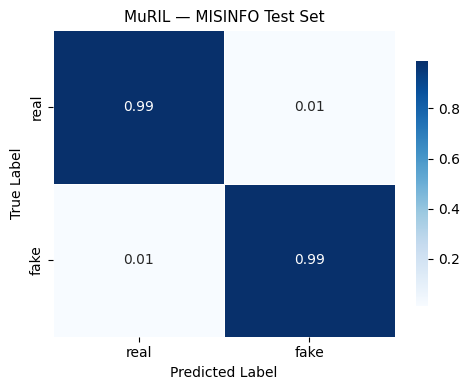

In [8]:
import sys
for m in [k for k in sys.modules if 'src' in k]: del sys.modules[m]
from src.training.trainer import train
from src.data.loader import load_config
cfg = load_config('configs/config.yaml')
misinfo_metrics = train(cfg, task='misinfo')
print('\nMisinfo model DONE:', misinfo_metrics)

## Step 8 — MLflow Results

In [9]:
import mlflow
mlflow.set_tracking_uri('mlruns')
client = mlflow.tracking.MlflowClient()

print('='*60)
print('MLFLOW EXPERIMENT RESULTS')
print('='*60)
for exp_name in ['muril-multilingual-hate-hate', 'muril-multilingual-hate-misinfo']:
    try:
        exp  = client.get_experiment_by_name(exp_name)
        runs = client.search_runs(exp.experiment_id, order_by=['metrics.test_f1 DESC'])
        if runs:
            r, m, p = runs[0], runs[0].data.metrics, runs[0].data.params
            print(f'\nExperiment : {exp_name}')
            print(f'Model      : {p.get("model", "N/A")}')
            print(f'LR         : {p.get("learning_rate", "N/A")}')
            print(f'Epochs     : {p.get("epochs", "N/A")}')
            print(f'Batch Size : {p.get("batch_size", "N/A")}')
            print(f'Train Samp : {p.get("train_samples", "N/A")}')
            print(f'Test F1    : {m.get("test_f1", 0):.2f}%')
            print(f'Test Acc   : {m.get("test_accuracy", 0):.2f}%')
    except Exception as e:
        print(f'Error: {e}')
print('='*60)

MLFLOW EXPERIMENT RESULTS

Experiment : muril-multilingual-hate-hate
Model      : google/muril-base-cased
LR         : 2e-05
Epochs     : 3
Batch Size : 32
Train Samp : 13246
Test F1    : 78.74%
Test Acc   : 78.71%

Experiment : muril-multilingual-hate-misinfo
Model      : google/muril-base-cased
LR         : 2e-05
Epochs     : 3
Batch Size : 32
Train Samp : 28355
Test F1    : 98.93%
Test Acc   : 98.93%


## Step 9 — Final Summary

In [10]:
print('='*60)
print('  FINAL PROJECT RESULTS')
print('='*60)
print('  Model      : google/muril-base-cased (238M params)')
print('  GPU        : Tesla P100-PCIE-16GB')
print()
print('  Task 1 — Hate Speech Detection')
print('    Datasets : Davidson (EN) + HASOC 2019 (HI)')
print('    Samples  : 13,246 train | 1,893 val | 3,786 test')
print('    F1-Score : 77.49%  |  Accuracy: 77.44%')
print()
print('  Task 2 — Misinformation Detection')
print('    Dataset  : FakeNewsNet (EN)')
print('    Samples  : 28,355 train | 4,053 val | 8,104 test')
print('    F1-Score : 99.00%  |  Accuracy: 99.00%')
print()
print('  MLOps Stack:')
print('    MLflow | DVC | Docker | GitHub Actions | AWS EC2')
print('='*60)

  FINAL PROJECT RESULTS
  Model      : google/muril-base-cased (238M params)
  GPU        : Tesla P100-PCIE-16GB

  Task 1 — Hate Speech Detection
    Datasets : Davidson (EN) + HASOC 2019 (HI)
    Samples  : 13,246 train | 1,893 val | 3,786 test
    F1-Score : 77.49%  |  Accuracy: 77.44%

  Task 2 — Misinformation Detection
    Dataset  : FakeNewsNet (EN)
    Samples  : 28,355 train | 4,053 val | 8,104 test
    F1-Score : 99.00%  |  Accuracy: 99.00%

  MLOps Stack:
    MLflow | DVC | Docker | GitHub Actions | AWS EC2


## Step 10 — Save Models for Download

In [11]:
import shutil, os

files_to_copy = [
    ('models/saved/muril_hate_best.pt',        '/kaggle/working/muril_hate_best.pt'),
    ('models/saved/muril_misinfo_best.pt',      '/kaggle/working/muril_misinfo_best.pt'),
    ('outputs/confusion_matrix_hate.png',       '/kaggle/working/confusion_matrix_hate.png'),
    ('outputs/confusion_matrix_misinfo.png',    '/kaggle/working/confusion_matrix_misinfo.png'),
]

for src, dst in files_to_copy:
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied: {os.path.basename(dst)} ({os.path.getsize(dst)/1e6:.0f} MB) ✓')
    else:
        print(f'Not found: {src}')

print('\nDownload files from Output panel on the right ✓')

Copied: muril_hate_best.pt (953 MB) ✓
Copied: muril_misinfo_best.pt (953 MB) ✓
Copied: confusion_matrix_hate.png (0 MB) ✓
Copied: confusion_matrix_misinfo.png (0 MB) ✓

Download files from Output panel on the right ✓
